# Predicting `measured_mem_total`

Simple regression model using all non-target columns from a CSV.
Features include `size`, `attempts`, run statistics (`stop_nodes`, `stop_classes`, `stop_time`, `last_*`), `estimated_mem_egraph`, parsed `stop_reason`, and term-derived structural features.

In [34]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

CSV_PATH = Path("../output_new_100.csv")
TARGET = "measured_mem_total"
SEED = 42

In [35]:
df = pl.read_csv(CSV_PATH)
df.head()

size,term,attempts,stop_reason,stop_nodes,stop_classes,stop_time,last_nodes,last_classes,last_time,measured_mem_total,estimated_mem_egraph
i64,str,i64,str,i64,i64,f64,i64,i64,f64,i64,i64
10,"""(sin (- (d (cos (pow (pow y 1)…",614,"""NodeLimit(546248)""",546175,59293,1.826576,10058,2434,1.792795,121477292,50025684
10,"""(cos (+ (sqrt (d (ln (sqrt y))…",584,"""TimeLimit(30.312127394)""",9272406,74567,36.29525,34825,5881,36.179921,2056744368,689483540
10,"""(/ (sqrt 2) (cos (sin (- (d (s…",155,"""TimeLimit(18.033149446)""",5987334,74568,21.885931,16895,5882,21.819082,1056147852,387786502
11,"""(* 1 (- (+ x x) (+ x (sin (sin…",259,"""NodeLimit(229894)""",228216,46864,0.649499,29041,2378,0.562966,39907520,26442034
11,"""(+ y (- (- (+ 2 x) 2) (sqrt 0)…",248,"""NodeLimit(106699)""",105873,2460,0.387789,98237,3591,0.085356,12685952,6873682


## Feature engineering

- Parse `stop_reason` into `stop_kind` (categorical: `NodeLimit` / `TimeLimit` / ...) and `stop_limit` (the numeric inside the parens).
- Drop `term` and `size`/`attempts` — keep only run statistics that the Rust function will have available.

In [36]:
def parse_stop(reason: str) -> tuple[str, float]:
    m = re.match(r"([A-Za-z]+)(?:\(([^)]+)\))?", reason)
    if m is None:
        return (reason, 0.0)
    kind = m.group(1)
    raw = m.group(2)
    val = float(raw) if raw is not None else 0.0
    return (kind, val)


rows = df.to_dicts()
for r in rows:
    kind, limit = parse_stop(r["stop_reason"])
    r["stop_kind"] = kind
    r["stop_limit"] = limit

feat_df = pl.DataFrame(rows)
feat_df = feat_df.to_dummies(columns=["stop_kind"])
feat_df.head()

size,term,attempts,stop_reason,stop_nodes,stop_classes,stop_time,last_nodes,last_classes,last_time,measured_mem_total,estimated_mem_egraph,stop_kind_NodeLimit,stop_kind_TimeLimit,stop_limit
i64,str,i64,str,i64,i64,f64,i64,i64,f64,i64,i64,u8,u8,f64
10,"""(sin (- (d (cos (pow (pow y 1)…",614,"""NodeLimit(546248)""",546175,59293,1.826576,10058,2434,1.792795,121477292,50025684,1,0,546248.0
10,"""(cos (+ (sqrt (d (ln (sqrt y))…",584,"""TimeLimit(30.312127394)""",9272406,74567,36.29525,34825,5881,36.179921,2056744368,689483540,0,1,30.312127
10,"""(/ (sqrt 2) (cos (sin (- (d (s…",155,"""TimeLimit(18.033149446)""",5987334,74568,21.885931,16895,5882,21.819082,1056147852,387786502,0,1,18.033149
11,"""(* 1 (- (+ x x) (+ x (sin (sin…",259,"""NodeLimit(229894)""",228216,46864,0.649499,29041,2378,0.562966,39907520,26442034,1,0,229894.0
11,"""(+ y (- (- (+ 2 x) 2) (sqrt 0)…",248,"""NodeLimit(106699)""",105873,2460,0.387789,98237,3591,0.085356,12685952,6873682,1,0,106699.0


In [37]:
drop_cols = [TARGET, "term", "stop_reason", "size", "attempts"]
feature_cols = [c for c in feat_df.columns if c not in drop_cols]

X = feat_df.select(feature_cols).to_numpy().astype(np.float64)
y = feat_df.get_column(TARGET).to_numpy().astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X.shape, y.shape, X_train.shape, X_test.shape

((100, 10), (100,), (80, 10), (20, 10))

## Models

In [38]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    r2 = r2_score(y_te, pred)
    print(f"{name:25s}  MAE={mae:.3e}  R2={r2:.4f}")
    return model, pred


linreg = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
ridge = Pipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
pca_lr = Pipeline(
    [
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=SEED)),
        ("lr", LinearRegression()),
    ]
)

_, lin_pred = evaluate("LinearRegression", linreg, X_train, y_train, X_test, y_test)
_, _ = evaluate("Ridge(alpha=1.0)", ridge, X_train, y_train, X_test, y_test)
pca_fit, _ = evaluate("PCA(0.95) + LinReg", pca_lr, X_train, y_train, X_test, y_test)

n_kept = pca_fit.named_steps["pca"].n_components_
print(f"\nPCA kept {n_kept} components (95% variance) out of {X_train.shape[1]}")

LinearRegression           MAE=2.249e+07  R2=0.9875
Ridge(alpha=1.0)           MAE=3.705e+07  R2=0.9626
PCA(0.95) + LinReg         MAE=4.184e+07  R2=0.9881

PCA kept 4 components (95% variance) out of 10


## Feature importance (linear model)

Importance is read off the *standardized* coefficients of the fitted `LinearRegression`. Because every feature has unit variance after the `StandardScaler`, the magnitude of each coefficient is directly comparable: it answers "how much does the prediction move (in target units) when this feature moves by one standard deviation?"

feature                              std_coef
estimated_mem_egraph               +5.357e+08
last_time                          -5.056e+08
stop_time                          +4.247e+08
stop_nodes                         +3.832e+07
stop_classes                       -3.172e+07
stop_kind_NodeLimit                +1.162e+07
stop_kind_TimeLimit                -1.162e+07
last_nodes                         -1.153e+07
last_classes                       +5.768e+06
stop_limit                         +1.354e+06


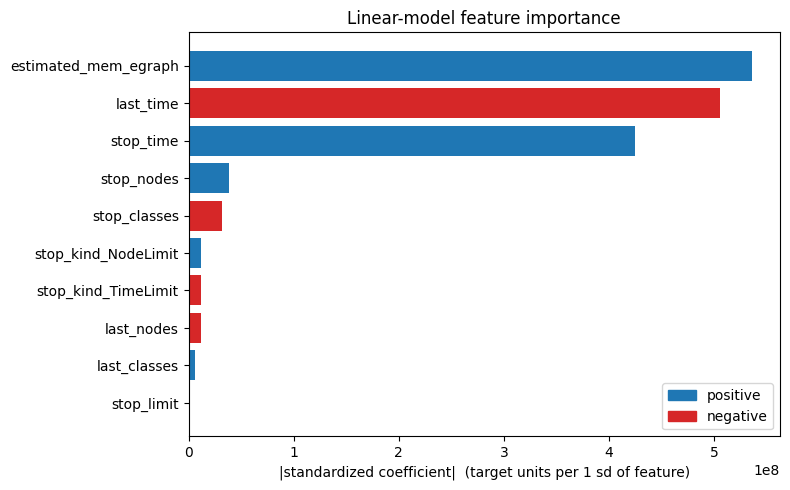

In [39]:
scaled_coefs = linreg.named_steps["lr"].coef_
order = np.argsort(np.abs(scaled_coefs))[::-1]

print(f"{'feature':30s} {'std_coef':>14s}")
for i in order:
    print(f"{feature_cols[i]:30s} {scaled_coefs[i]:+14.3e}")

fig, ax = plt.subplots(figsize=(8, 5))
sorted_names = [feature_cols[i] for i in order]
sorted_vals = scaled_coefs[order]
colors = ["#d62728" if v < 0 else "#1f77b4" for v in sorted_vals]
ax.barh(range(len(sorted_names)), np.abs(sorted_vals), color=colors)
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names)
ax.invert_yaxis()
ax.set_xlabel("|standardized coefficient|  (target units per 1 sd of feature)")
ax.set_title("Linear-model feature importance")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="#1f77b4", label="positive"),
        plt.Rectangle((0, 0), 1, 1, color="#d62728", label="negative"),
    ],
    loc="lower right",
)
fig.tight_layout()
plt.show()

## Predicted vs. actual and residuals (linear model)

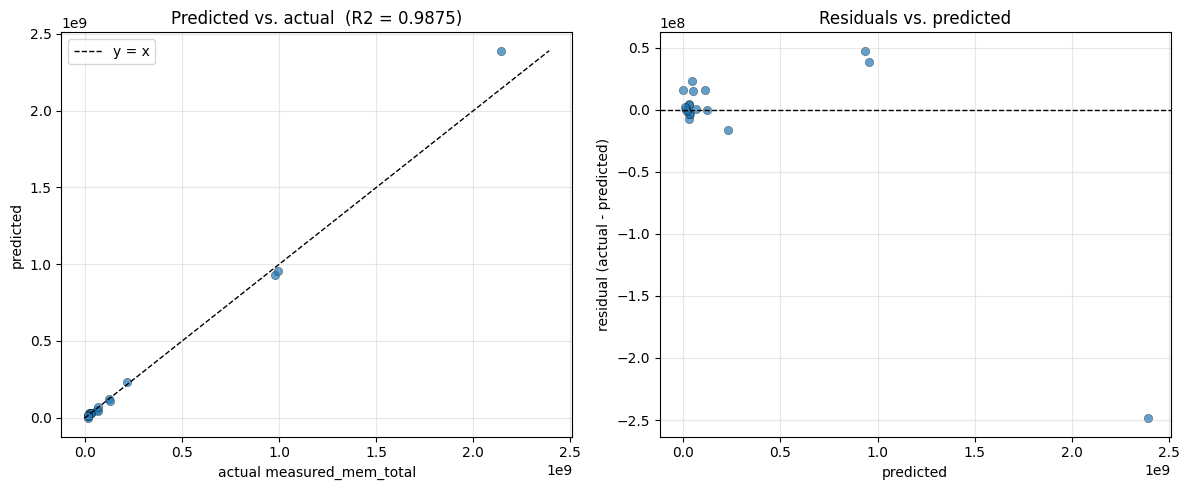

In [40]:
residuals = y_test - lin_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
lo = float(min(y_test.min(), lin_pred.min()))
hi = float(max(y_test.max(), lin_pred.max()))
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
ax.scatter(y_test, lin_pred, alpha=0.7, edgecolor="k", linewidth=0.3)
ax.set_xlabel("actual measured_mem_total")
ax.set_ylabel("predicted")
ax.set_title(f"Predicted vs. actual  (R2 = {r2_score(y_test, lin_pred):.4f})")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.axhline(0, color="k", lw=1, ls="--")
ax.scatter(lin_pred, residuals, alpha=0.7, edgecolor="k", linewidth=0.3)
ax.set_xlabel("predicted")
ax.set_ylabel("residual (actual - predicted)")
ax.set_title("Residuals vs. predicted")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Feature/target correlation heatmap

The bottom row / right column shows correlation of each feature with the target. Off-diagonal entries reveal feature collinearity (pairs that move together hurt linear-model coefficient interpretability).

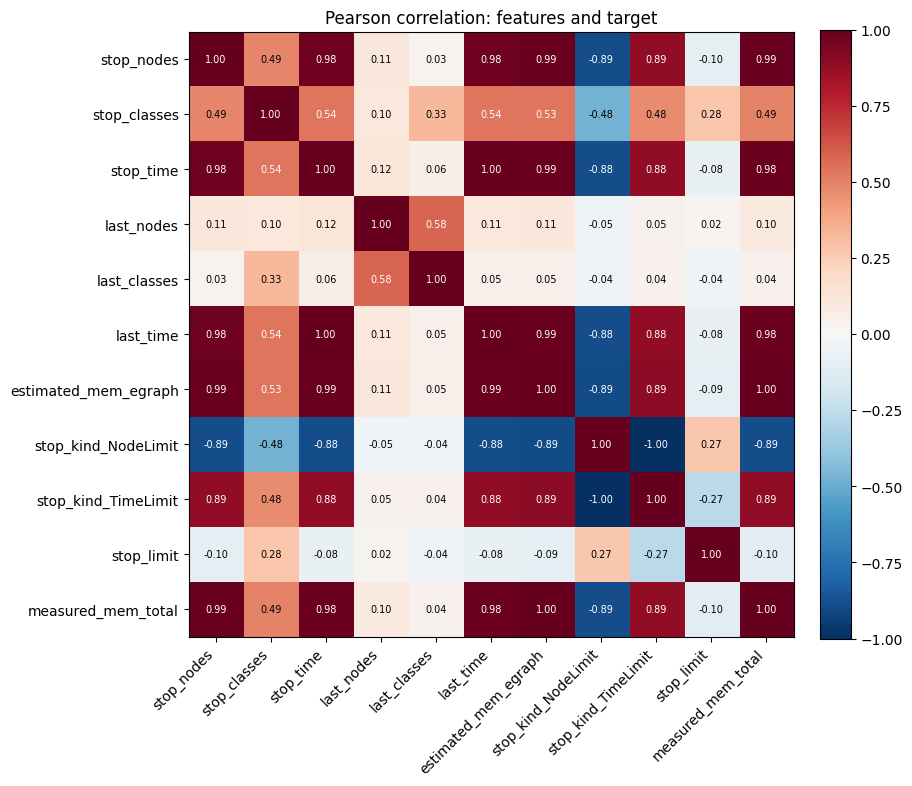

In [41]:
corr_data = np.column_stack([X, y])
corr_labels = feature_cols + [TARGET]
corr = np.corrcoef(corr_data, rowvar=False)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_labels)))
ax.set_yticks(range(len(corr_labels)))
ax.set_xticklabels(corr_labels, rotation=45, ha="right")
ax.set_yticklabels(corr_labels)
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        ax.text(
            j,
            i,
            f"{corr[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if abs(corr[i, j]) > 0.5 else "black",
            fontsize=7,
        )
ax.set_title("Pearson correlation: features and target")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## PCA explained-variance curve and component sweep

cumulative explained variance per #components:
    1: 0.6059
    2: 0.7849
    3: 0.8963
    4: 0.9517
    5: 0.9764
    6: 0.9959
    7: 0.9998
    8: 1.0000
    9: 1.0000
   10: 1.0000

LinReg on first k principal components:
  k=  1  MAE=4.851e+07  R2=0.9819
  k=  2  MAE=4.500e+07  R2=0.9847
  k=  3  MAE=4.832e+07  R2=0.9837
  k=  5  MAE=3.699e+07  R2=0.9924
  k=  8  MAE=2.230e+07  R2=0.9873
  k= 10  MAE=2.249e+07  R2=0.9875


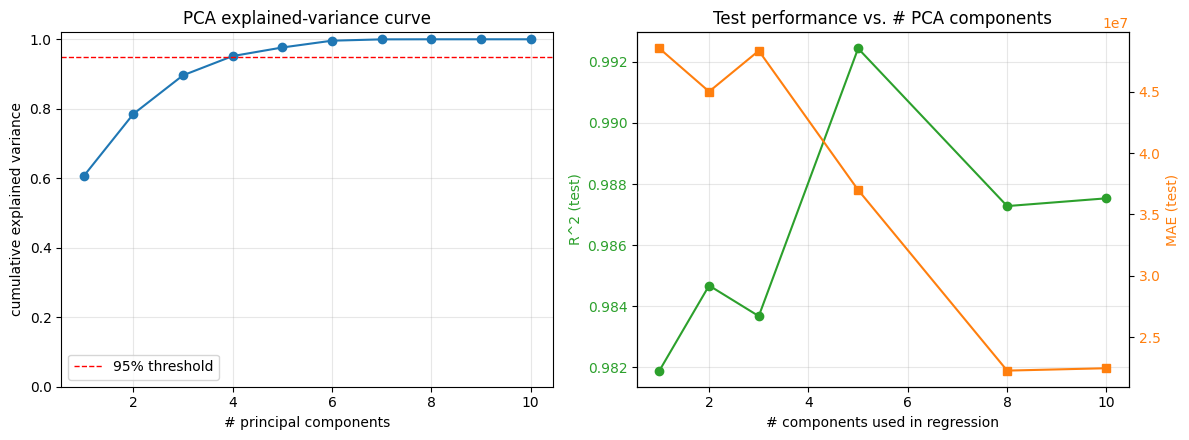

In [42]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

pca_full = PCA(random_state=SEED).fit(X_train_s)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
print("cumulative explained variance per #components:")
for i, v in enumerate(cum_var, start=1):
    print(f"  {i:3d}: {v:.4f}")

ks = [k for k in [1, 2, 3, 5, 8, 12, 16, X_train.shape[1]] if k <= X_train.shape[1]]
sweep_r2 = []
sweep_mae = []
print("\nLinReg on first k principal components:")
for k in ks:
    pipe = Pipeline(
        [
            ("pca", PCA(n_components=k, random_state=SEED)),
            ("lr", LinearRegression()),
        ]
    )
    pipe.fit(X_train_s, y_train)
    pred = pipe.predict(X_test_s)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    sweep_r2.append(r2)
    sweep_mae.append(mae)
    print(f"  k={k:3d}  MAE={mae:.3e}  R2={r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
xs = np.arange(1, len(cum_var) + 1)
ax.plot(xs, cum_var, marker="o")
ax.axhline(0.95, color="r", ls="--", lw=1, label="95% threshold")
ax.set_xlabel("# principal components")
ax.set_ylabel("cumulative explained variance")
ax.set_title("PCA explained-variance curve")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(ks, sweep_r2, marker="o", color="tab:green", label="R^2")
ax.set_xlabel("# components used in regression")
ax.set_ylabel("R^2 (test)", color="tab:green")
ax.tick_params(axis="y", labelcolor="tab:green")
ax.grid(alpha=0.3)
ax2 = ax.twinx()
ax2.plot(ks, sweep_mae, marker="s", color="tab:orange", label="MAE")
ax2.set_ylabel("MAE (test)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax.set_title("Test performance vs. # PCA components")

fig.tight_layout()
plt.show()

## Export linear model as Rust constants

Folds the `StandardScaler` into the coefficients so the Rust function can use raw feature values:

`y = intercept_raw + sum(coef_raw[i] * x_raw[i])` where
`coef_raw[i] = coef[i] / scale[i]` and
`intercept_raw = intercept - sum(coef[i] * mean[i] / scale[i])`.

In [43]:
scaler = linreg.named_steps["scale"]
lr = linreg.named_steps["lr"]

mean = scaler.mean_
scale = scaler.scale_
coef_scaled = lr.coef_
intercept_scaled = lr.intercept_

coef_raw = coef_scaled / scale
intercept_raw = intercept_scaled - float(np.sum(coef_scaled * mean / scale))

# sanity-check: predictions match the sklearn pipeline
manual = X_test @ coef_raw + intercept_raw
sk = linreg.predict(X_test)
print(f"max |manual - sklearn| = {np.max(np.abs(manual - sk)):.3e}")

print("\nfeatures (in order):")
for i, name in enumerate(feature_cols):
    print(f"  {i:2d}  {name:25s}  coef={coef_raw[i]:+.6e}")
print(f"\nintercept = {intercept_raw:+.6e}")

max |manual - sklearn| = 9.537e-07

features (in order):
   0  stop_nodes                 coef=+1.728212e+01
   1  stop_classes               coef=-7.280704e+02
   2  stop_time                  coef=+4.587599e+07
   3  last_nodes                 coef=-4.782449e+02
   4  last_classes               coef=+1.110653e+03
   5  last_time                  coef=-5.457025e+07
   6  estimated_mem_egraph       coef=+3.325452e+00
   7  stop_kind_NodeLimit        coef=+3.677274e+07
   8  stop_kind_TimeLimit        coef=-3.677274e+07
   9  stop_limit                 coef=+3.497743e+00

intercept = -3.332998e+07


In [44]:
def fmt_rust(x: float) -> str:
    s = f"{x:+.10e}"
    mantissa, exp = s.split("e")
    sign = mantissa[0]
    digits = mantissa[1:]
    int_part, frac_part = digits.split(".")
    # group fractional digits into chunks of 3 from the left for readability
    frac_chunks = [frac_part[i : i + 3] for i in range(0, len(frac_part), 3)]
    frac_grouped = "_".join(frac_chunks)
    return f"{sign}{int_part}.{frac_grouped}e{exp}"


print(f"const INTERCEPT: f64 = {fmt_rust(intercept_raw)};")
print(f"const COEFS: [f64; {len(feature_cols)}] = [")
for name, c in zip(feature_cols, coef_raw):
    print(f"    {fmt_rust(c)}, // {name}")
print("];")
print()
print("features in order:")
for name in feature_cols:
    print(f"  {name}")

const INTERCEPT: f64 = -3.332_997_509_4e+07;
const COEFS: [f64; 10] = [
    +1.728_212_245_9e+01, // stop_nodes
    -7.280_704_373_3e+02, // stop_classes
    +4.587_598_965_2e+07, // stop_time
    -4.782_449_196_5e+02, // last_nodes
    +1.110_653_182_3e+03, // last_classes
    -5.457_025_325_1e+07, // last_time
    +3.325_451_938_8e+00, // estimated_mem_egraph
    +3.677_274_422_9e+07, // stop_kind_NodeLimit
    -3.677_274_422_9e+07, // stop_kind_TimeLimit
    +3.497_742_819_0e+00, // stop_limit
];

features in order:
  stop_nodes
  stop_classes
  stop_time
  last_nodes
  last_classes
  last_time
  estimated_mem_egraph
  stop_kind_NodeLimit
  stop_kind_TimeLimit
  stop_limit
